In [2]:
import os
import cv2
import torch
import albumentations as A
from torch.utils.data import Dataset, DataLoader, random_split
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
import torch.nn.functional as F
from torchvision import models, transforms

In [6]:
train_transform = A.Compose([
    A.RandomResizedCrop(size=(128, 128), scale=(0.8, 1.0)),
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=15, p=0.5),
    A.GaussianBlur(blur_limit=3, p=0.3),
    A.GaussNoise(std_range=(0.02, 0.05), p=0.3),
])


test_transform = A.Compose([
    A.Resize(128, 128)
])


In [8]:
class UTKFaceDataset(Dataset):
    def __init__(self, folder, transform=None):
        self.paths = []
        self.ages = []
        self.genders = []
        self.transform = transform

        for file in os.listdir(folder):
            parts = file.split('_')
            if len(parts) < 2:
                continue
            if not parts[0].isdigit() or not parts[1].isdigit():
                continue

            age = int(parts[0])
            gender = int(parts[1])

            self.paths.append(os.path.join(folder, file))
            self.ages.append(age)
            self.genders.append(gender)

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = cv2.imread(self.paths[idx])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        if self.transform:
            img = self.transform(image=img)["image"]

        img = img.astype(np.float32) / 255.0
        img = torch.tensor(img).permute(2, 0, 1)

        age = torch.tensor(self.ages[idx], dtype=torch.float32) / 100.0
        gender = torch.tensor(self.genders[idx], dtype=torch.float32)

        return img, gender, age


In [12]:
full_dataset = UTKFaceDataset('/kaggle/input/dataset/UTKFace')

train_size = int(0.7 * len(full_dataset))
val_size = int(0.15 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size

generator = torch.Generator().manual_seed(42)

train_ds, val_ds, test_ds = random_split(
    full_dataset,
    [train_size, val_size, test_size],
    generator=generator
)

In [15]:
train_ds.dataset.transform = train_transform
val_ds.dataset.transform   = test_transform
test_ds.dataset.transform  = test_transform

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=64, shuffle=False)
test_loader  = DataLoader(test_ds, batch_size=64, shuffle=False)

In [17]:
class AgeGenderNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(32),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(64),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(128),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, 3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(256),
            nn.MaxPool2d(2),

            nn.Conv2d(256, 512, 3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(512),
            nn.MaxPool2d(2),
        )

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.3)
        )

        self.gender_out = nn.Linear(512 * 4 * 4, 1)
        self.age_out = nn.Linear(512 * 4 * 4, 1)

    def forward(self, x):
        x = self.conv(x)
        x = self.fc(x)

        gender = torch.sigmoid(self.gender_out(x))  
        age = self.age_out(x)                  
        return gender, age


In [18]:
model = AgeGenderNet().cuda()
criterion_gender = nn.BCELoss()
criterion_age = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

In [19]:
history = {
    "train_gender_loss": [],
    "val_gender_loss": [],
    "train_age_loss": [],
    "val_age_loss": [],
    "train_total_loss": [],
    "val_total_loss": [],
    "train_gender_acc": [],
    "val_gender_acc": [],
    "train_age_mae": [],
    "val_age_mae": []
}

def gender_accuracy(pred, true):
    pred = (pred > 0.5).float()
    return (pred == true).float().mean().item()

def age_mae(pred, true):
    return torch.abs(pred - true).mean().item()


In [20]:
patience = 10
best_val_loss = float('inf')
counter = 0

for epoch in range(20):

    model.train()
    train_g_loss = train_a_loss = train_total = 0
    train_acc = train_mae = 0
    batches = 0

    for imgs, genders, ages in train_loader:
        imgs, genders, ages = imgs.cuda(), genders.cuda(), ages.cuda()

        optimizer.zero_grad()
        pred_gender, pred_age = model(imgs)

        loss_g = criterion_gender(pred_gender, genders.unsqueeze(1))
        loss_a = criterion_age(pred_age, ages.unsqueeze(1))
        loss = loss_g + loss_a

        loss.backward()
        optimizer.step()

        train_g_loss += loss_g.item()
        train_a_loss += loss_a.item()
        train_total += loss.item()
        train_acc += gender_accuracy(pred_gender, genders.unsqueeze(1))
        train_mae += age_mae(pred_age, ages.unsqueeze(1))
        batches += 1

    history["train_gender_loss"].append(train_g_loss / batches)
    history["train_age_loss"].append(train_a_loss / batches)
    history["train_total_loss"].append(train_total / batches)
    history["train_gender_acc"].append(train_acc / batches)
    history["train_age_mae"].append(train_mae / batches)

    # ===== Validation =====
    model.eval()
    val_g_loss = val_a_loss = val_total = 0
    val_acc = val_mae = 0
    v_batches = 0

    with torch.no_grad():
        for imgs, genders, ages in val_loader:
            imgs, genders, ages = imgs.cuda(), genders.cuda(), ages.cuda()

            pred_gender, pred_age = model(imgs)

            loss_g = criterion_gender(pred_gender, genders.unsqueeze(1))
            loss_a = criterion_age(pred_age, ages.unsqueeze(1))
            loss = loss_g + loss_a

            val_g_loss += loss_g.item()
            val_a_loss += loss_a.item()
            val_total += loss.item()
            val_acc += gender_accuracy(pred_gender, genders.unsqueeze(1))
            val_mae += age_mae(pred_age, ages.unsqueeze(1))
            v_batches += 1

    val_total_loss_epoch = val_total / v_batches

    history["val_gender_loss"].append(val_g_loss / v_batches)
    history["val_age_loss"].append(val_a_loss / v_batches)
    history["val_total_loss"].append(val_total_loss_epoch)
    history["val_gender_acc"].append(val_acc / v_batches)
    history["val_age_mae"].append(val_mae / v_batches)

    print(f"Epoch {epoch+1}:")
    print(f"  Train Loss: {history['train_total_loss'][-1]:.4f},  Val Loss: {val_total_loss_epoch:.4f}")
    print(f"  Train Acc:  {history['train_gender_acc'][-1]:.4f},  Val Acc:  {history['val_gender_acc'][-1]:.4f}")
    print(f"  Train MAE:  {history['train_age_mae'][-1]:.4f}, Val MAE:  {history['val_age_mae'][-1]:.4f}")

    if val_total_loss_epoch < best_val_loss:
        best_val_loss = val_total_loss_epoch
        counter = 0
        torch.save(model.state_dict(), "best_model.pt") 
    else:
        counter += 1
        if counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            model.load_state_dict(torch.load("best_model.pt"))
            break


Epoch 1:
  Train Loss: 0.9778,  Val Loss: 0.6588
  Train Acc:  0.7776,  Val Acc:  0.8237
  Train MAE:  0.5373, Val MAE:  0.4034
Epoch 2:
  Train Loss: 0.6355,  Val Loss: 0.4113
  Train Acc:  0.8361,  Val Acc:  0.8476
  Train MAE:  0.3904, Val MAE:  0.2034
Epoch 3:
  Train Loss: 0.4945,  Val Loss: 0.3521
  Train Acc:  0.8611,  Val Acc:  0.8721
  Train MAE:  0.3271, Val MAE:  0.1837
Epoch 4:
  Train Loss: 0.4091,  Val Loss: 0.3117
  Train Acc:  0.8864,  Val Acc:  0.8843
  Train MAE:  0.2861, Val MAE:  0.1613
Epoch 5:
  Train Loss: 0.3390,  Val Loss: 0.3047
  Train Acc:  0.9034,  Val Acc:  0.8849
  Train MAE:  0.2482, Val MAE:  0.1382
Epoch 6:
  Train Loss: 0.2816,  Val Loss: 0.2906
  Train Acc:  0.9177,  Val Acc:  0.8894
  Train MAE:  0.2143, Val MAE:  0.1466
Epoch 7:
  Train Loss: 0.2349,  Val Loss: 0.2550
  Train Acc:  0.9335,  Val Acc:  0.9059
  Train MAE:  0.1877, Val MAE:  0.1210
Epoch 8:
  Train Loss: 0.1957,  Val Loss: 0.2797
  Train Acc:  0.9452,  Val Acc:  0.9021
  Train MAE:  0

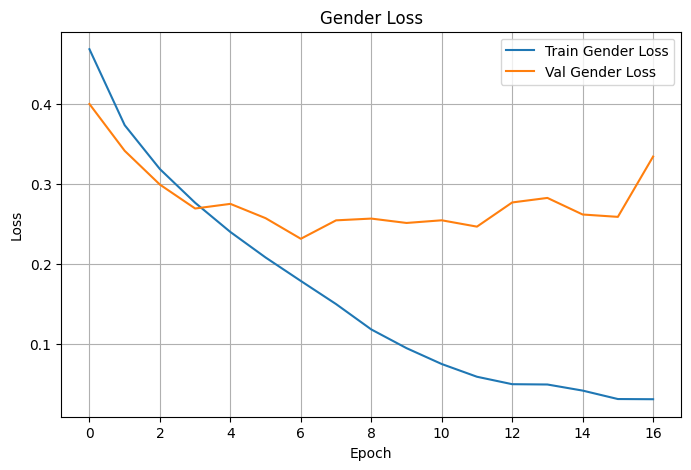

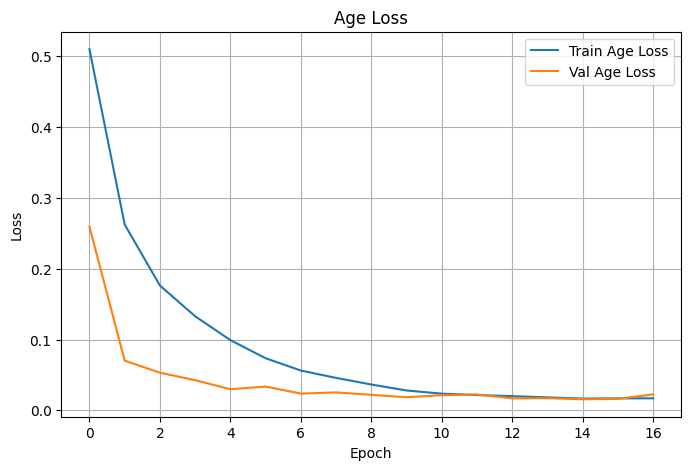

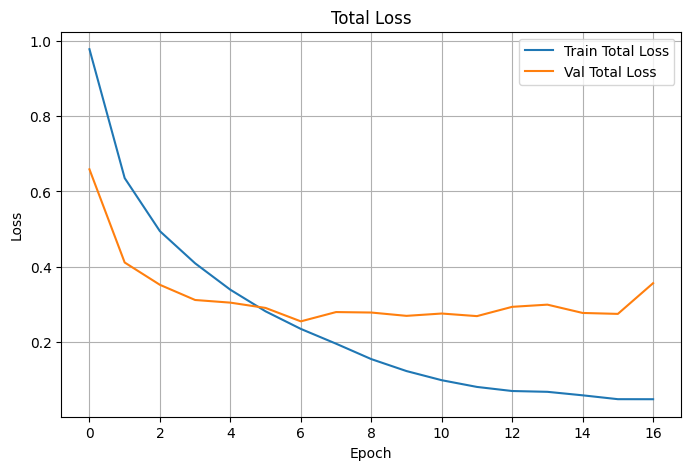

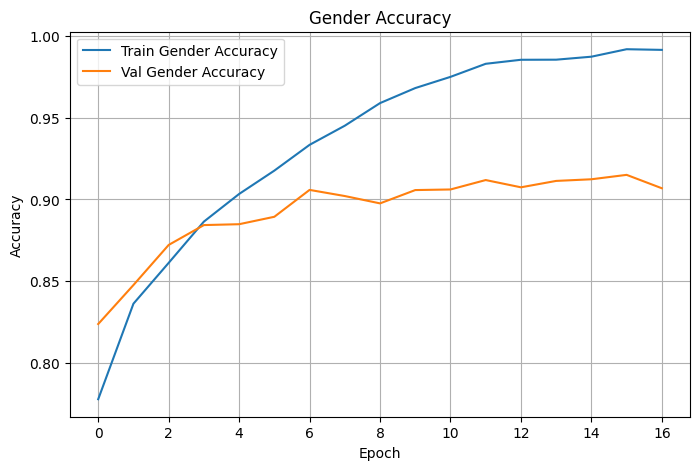

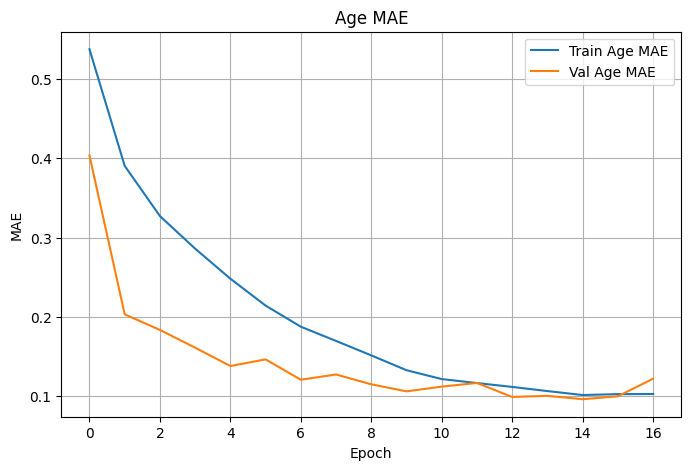

In [21]:
plt.figure(figsize=(8,5))
plt.plot(history["train_gender_loss"], label="Train Gender Loss")
plt.plot(history["val_gender_loss"], label="Val Gender Loss")
plt.title("Gender Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8,5))
plt.plot(history["train_age_loss"], label="Train Age Loss")
plt.plot(history["val_age_loss"], label="Val Age Loss")
plt.title("Age Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8,5))
plt.plot(history["train_total_loss"], label="Train Total Loss")
plt.plot(history["val_total_loss"], label="Val Total Loss")
plt.title("Total Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8,5))
plt.plot(history["train_gender_acc"], label="Train Gender Accuracy")
plt.plot(history["val_gender_acc"], label="Val Gender Accuracy")
plt.title("Gender Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8,5))
plt.plot(history["train_age_mae"], label="Train Age MAE")
plt.plot(history["val_age_mae"], label="Val Age MAE")
plt.title("Age MAE")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.legend()
plt.grid(True)
plt.show()


In [22]:
def evaluate(model, test_loader):
    model.eval()
    gender_correct = 0
    total = 0

    mae_age = 0.0

    with torch.no_grad():
        for imgs, genders, ages in test_loader:
            imgs = imgs.cuda()
            genders = genders.cuda().float().unsqueeze(1)    # [batch,1]
            ages = ages.cuda().float().unsqueeze(1)

            pred_gender, pred_age = model(imgs)

            # ----- Gender Accuracy -----
            pred_gender_label = (pred_gender > 0.5).float()
            gender_correct += (pred_gender_label == genders).sum().item()

            # ----- MAE Age -----
            mae_age += torch.abs(pred_age - ages).sum().item()

            total += imgs.size(0)

    gender_acc = gender_correct / total
    mae_age = mae_age / total

    return gender_acc, mae_age

gender_acc, mae_age = evaluate(model, test_loader)

print("Gender Accuracy:", gender_acc)
print("Age MAE:", mae_age)


Gender Accuracy: 0.8858826680953656
Age MAE: 0.12041099813008098


In [23]:
torch.save(model.state_dict(), "age_gender.pt")

In [10]:
import os
import cv2
import torch
import albumentations as A
from torch.utils.data import Dataset, DataLoader, random_split
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
import torch.nn.functional as F
from torchvision import models, transforms

In [11]:
train_transform = A.Compose([
    A.RandomResizedCrop(size=(128, 128), scale=(0.8, 1.0)),
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=15, p=0.5),
    A.GaussianBlur(blur_limit=3, p=0.3),
    A.GaussNoise(std_range=(0.02, 0.05), p=0.3),
])


test_transform = A.Compose([
    A.Resize(128, 128)
])


In [14]:
class UTKFaceDataset(Dataset):
    def __init__(self, folder, transform=None):
        self.paths = []
        self.ages = []
        self.genders = []
        self.transform = transform

        for file in os.listdir(folder):
            parts = file.split('_')
            if len(parts) < 2:
                continue
            if not parts[0].isdigit() or not parts[1].isdigit():
                continue

            age = int(parts[0])
            gender = int(parts[1])

            self.paths.append(os.path.join(folder, file))
            self.ages.append(age)
            self.genders.append(gender)

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = cv2.imread(self.paths[idx])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        if self.transform:
            img = self.transform(image=img)["image"]

        img = img.astype(np.float32) / 255.0
        img = torch.tensor(img).permute(2, 0, 1)

        age = torch.tensor(self.ages[idx], dtype=torch.float32) / 100.0
        gender = torch.tensor(self.genders[idx], dtype=torch.float32)

        return img, gender, age


In [15]:
full_dataset = UTKFaceDataset('/kaggle/input/dataset/UTKFace')

train_size = int(0.7 * len(full_dataset))
val_size = int(0.15 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size

generator = torch.Generator().manual_seed(42)

train_ds, val_ds, test_ds = random_split(
    full_dataset,
    [train_size, val_size, test_size],
    generator=generator
)

In [16]:
train_ds.dataset.transform = train_transform
val_ds.dataset.transform   = test_transform
test_ds.dataset.transform  = test_transform

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=64, shuffle=False)
test_loader  = DataLoader(test_ds, batch_size=64, shuffle=False)

In [17]:
# =============================================================
# Model: ResNet50 Multi-task
# =============================================================
class AgeGenderResNet(nn.Module):
    def __init__(self):
        super().__init__()

        base = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

        # remove classification layer
        self.backbone = nn.Sequential(*list(base.children())[:-1])    # output: [B, 2048, 1, 1]

        self.dropout = nn.Dropout(0.4)

        self.gender_out = nn.Linear(2048, 1)
        self.age_out = nn.Linear(2048, 1)

    def forward(self, x):
        x = self.backbone(x)
        x = x.view(x.size(0), -1)
        x = self.dropout(x)

        gender = torch.sigmoid(self.gender_out(x))
        age = self.age_out(x)

        return gender, age


In [18]:
# =============================================================
# Setup training
# =============================================================
model = AgeGenderResNet().cuda()

criterion_gender = nn.BCELoss()
criterion_age = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

history = {
    "train_gender_loss": [],
    "val_gender_loss": [],
    "train_age_loss": [],
    "val_age_loss": [],
    "train_total_loss": [],
    "val_total_loss": [],
    "train_gender_acc": [],
    "val_gender_acc": [],
    "train_age_mae": [],
    "val_age_mae": []
}

def gender_accuracy(pred, true):
    pred = (pred > 0.5).float()
    return (pred == true).float().mean().item()

def age_mae(pred, true):
    return torch.abs(pred - true).mean().item()



Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 217MB/s]


In [19]:
# =============================================================
# Early stopping
# =============================================================
patience = 10
best_val_loss = float('inf')
counter = 0


# =============================================================
# TRAINING LOOP
# =============================================================
for epoch in range(20):

    model.train()
    train_g_loss = train_a_loss = train_total = 0
    train_acc = train_mae = 0
    batches = 0

    for imgs, genders, ages in train_loader:
        imgs, genders, ages = imgs.cuda(), genders.cuda(), ages.cuda()

        optimizer.zero_grad()
        pred_gender, pred_age = model(imgs)

        loss_g = criterion_gender(pred_gender, genders.unsqueeze(1))
        loss_a = criterion_age(pred_age, ages.unsqueeze(1))
        loss = loss_g + loss_a

        loss.backward()
        optimizer.step()

        train_g_loss += loss_g.item()
        train_a_loss += loss_a.item()
        train_total += loss.item()
        train_acc += gender_accuracy(pred_gender, genders.unsqueeze(1))
        train_mae += age_mae(pred_age, ages.unsqueeze(1))
        batches += 1

    history["train_gender_loss"].append(train_g_loss / batches)
    history["train_age_loss"].append(train_a_loss / batches)
    history["train_total_loss"].append(train_total / batches)
    history["train_gender_acc"].append(train_acc / batches)
    history["train_age_mae"].append(train_mae / batches)


    # ---------------- VALIDATION ----------------
    model.eval()
    val_g_loss = val_a_loss = val_total = 0
    val_acc = val_mae = 0
    v_batches = 0

    with torch.no_grad():
        for imgs, genders, ages in val_loader:
            imgs, genders, ages = imgs.cuda(), genders.cuda(), ages.cuda()

            pred_gender, pred_age = model(imgs)

            loss_g = criterion_gender(pred_gender, genders.unsqueeze(1))
            loss_a = criterion_age(pred_age, ages.unsqueeze(1))
            loss = loss_g + loss_a

            val_g_loss += loss_g.item()
            val_a_loss += loss_a.item()
            val_total += loss.item()
            val_acc += gender_accuracy(pred_gender, genders.unsqueeze(1))
            val_mae += age_mae(pred_age, ages.unsqueeze(1))
            v_batches += 1


    val_total_loss_epoch = val_total / v_batches

    history["val_gender_loss"].append(val_g_loss / v_batches)
    history["val_age_loss"].append(val_a_loss / v_batches)
    history["val_total_loss"].append(val_total_loss_epoch)
    history["val_gender_acc"].append(val_acc / v_batches)
    history["val_age_mae"].append(val_mae / v_batches)

    print(f"Epoch {epoch+1}:")
    print(f"  Train Loss: {history['train_total_loss'][-1]:.4f},  Val Loss: {val_total_loss_epoch:.4f}")
    print(f"  Train Acc:  {history['train_gender_acc'][-1]:.4f},  Val Acc:  {history['val_gender_acc'][-1]:.4f}")
    print(f"  Train MAE:  {history['train_age_mae'][-1]:.4f}, Val MAE:  {history['val_age_mae'][-1]:.4f}")


    # ---------------- EARLY STOPPING ----------------
    if val_total_loss_epoch < best_val_loss:
        best_val_loss = val_total_loss_epoch
        counter = 0
        torch.save(model.state_dict(), "best_resnet50_model.pt")
    else:
        counter += 1
        if counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            model.load_state_dict(torch.load("best_resnet50_model.pt"))
            break


Epoch 1:
  Train Loss: 0.3702,  Val Loss: 0.1979
  Train Acc:  0.8739,  Val Acc:  0.9283
  Train MAE:  0.2338, Val MAE:  0.0909
Epoch 2:
  Train Loss: 0.1795,  Val Loss: 0.2251
  Train Acc:  0.9476,  Val Acc:  0.9158
  Train MAE:  0.1658, Val MAE:  0.1029
Epoch 3:
  Train Loss: 0.1224,  Val Loss: 0.2039
  Train Acc:  0.9665,  Val Acc:  0.9323
  Train MAE:  0.1398, Val MAE:  0.0833
Epoch 4:
  Train Loss: 0.0960,  Val Loss: 0.2084
  Train Acc:  0.9742,  Val Acc:  0.9353
  Train MAE:  0.1247, Val MAE:  0.0729
Epoch 5:
  Train Loss: 0.0631,  Val Loss: 0.2678
  Train Acc:  0.9848,  Val Acc:  0.9278
  Train MAE:  0.1113, Val MAE:  0.0861
Epoch 6:
  Train Loss: 0.0499,  Val Loss: 0.2124
  Train Acc:  0.9889,  Val Acc:  0.9389
  Train MAE:  0.1017, Val MAE:  0.0673
Epoch 7:
  Train Loss: 0.0390,  Val Loss: 0.2524
  Train Acc:  0.9910,  Val Acc:  0.9309
  Train MAE:  0.0926, Val MAE:  0.0747
Epoch 8:
  Train Loss: 0.0375,  Val Loss: 0.2706
  Train Acc:  0.9911,  Val Acc:  0.9303
  Train MAE:  0

In [20]:
# =============================================================
# EVALUATION ON TEST SET
# =============================================================
def evaluate(model, test_loader):
    model.eval()
    gender_correct = 0
    total = 0
    mae_age = 0.0

    with torch.no_grad():
        for imgs, genders, ages in test_loader:
            imgs = imgs.cuda()
            genders = genders.cuda().float().unsqueeze(1)
            ages = ages.cuda().float().unsqueeze(1)

            pred_gender, pred_age = model(imgs)

            pred_gender_label = (pred_gender > 0.5).float()
            gender_correct += (pred_gender_label == genders).sum().item()

            mae_age += torch.abs(pred_age - ages).sum().item()
            total += imgs.size(0)

    gender_acc = gender_correct / total
    mae_age = mae_age / total

    return gender_acc, mae_age


gender_acc, mae_age = evaluate(model, test_loader)

print("Gender Accuracy:", gender_acc)
print("Age MAE:", mae_age)

Gender Accuracy: 0.9166889900884008
Age MAE: 0.09287242757836583


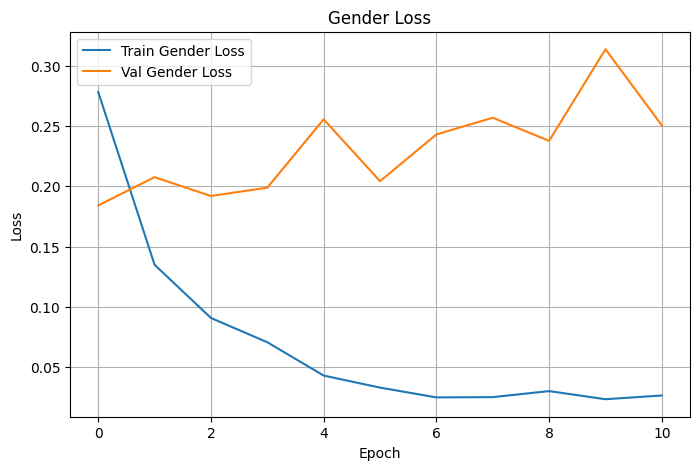

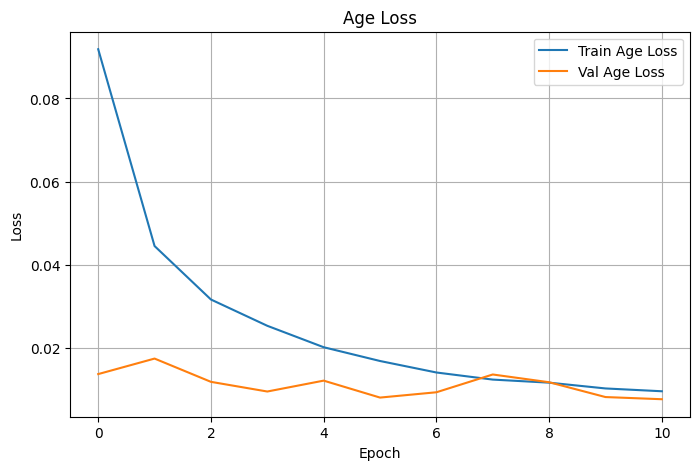

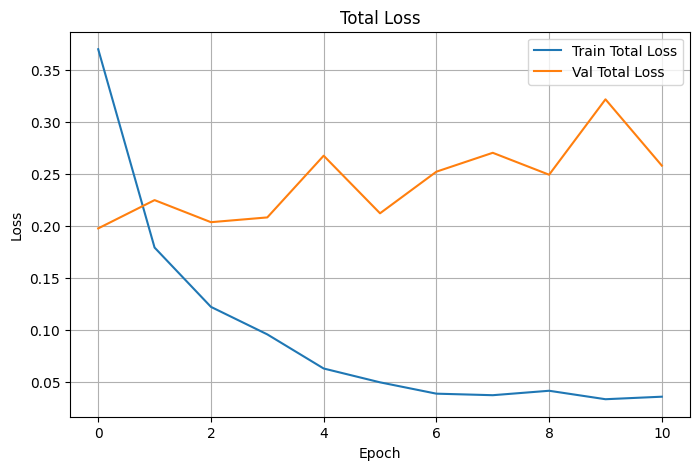

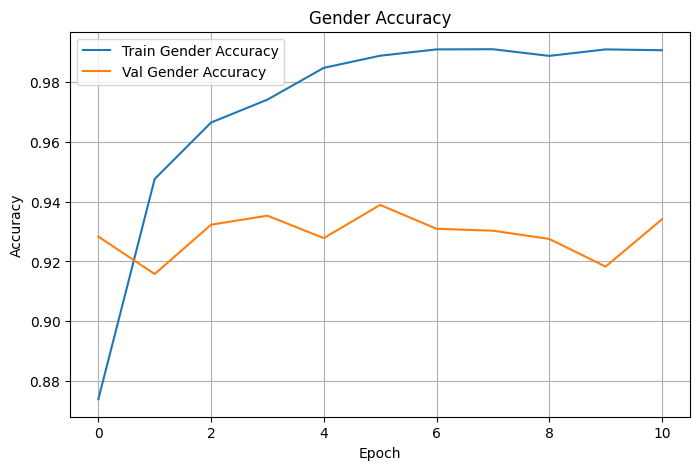

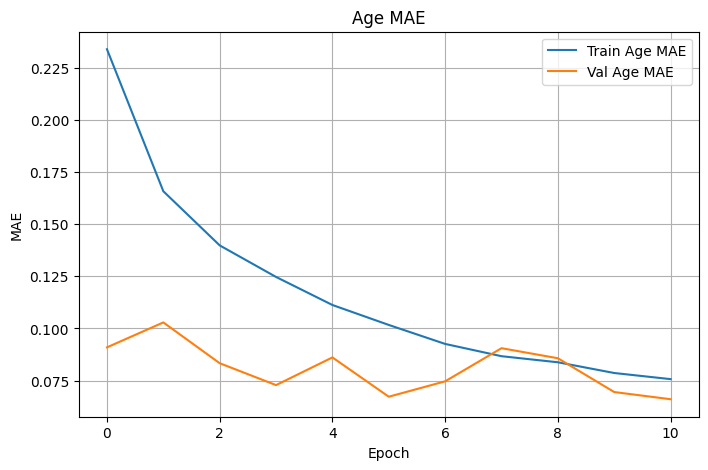

In [21]:
plt.figure(figsize=(8,5))
plt.plot(history["train_gender_loss"], label="Train Gender Loss")
plt.plot(history["val_gender_loss"], label="Val Gender Loss")
plt.title("Gender Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8,5))
plt.plot(history["train_age_loss"], label="Train Age Loss")
plt.plot(history["val_age_loss"], label="Val Age Loss")
plt.title("Age Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8,5))
plt.plot(history["train_total_loss"], label="Train Total Loss")
plt.plot(history["val_total_loss"], label="Val Total Loss")
plt.title("Total Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8,5))
plt.plot(history["train_gender_acc"], label="Train Gender Accuracy")
plt.plot(history["val_gender_acc"], label="Val Gender Accuracy")
plt.title("Gender Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8,5))
plt.plot(history["train_age_mae"], label="Train Age MAE")
plt.plot(history["val_age_mae"], label="Val Age MAE")
plt.title("Age MAE")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.legend()
plt.grid(True)
plt.show()


In [22]:
torch.save(model.state_dict(), "age_gender_resnet50.pt")

In [2]:
import os
import cv2
import torch
import albumentations as A
from torch.utils.data import Dataset, DataLoader, random_split
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
import torch.nn.functional as F
from torchvision import models, transforms

In [6]:
train_transform = A.Compose([
    A.RandomResizedCrop(size=(128, 128), scale=(0.8, 1.0)),
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=15, p=0.5),
    A.GaussianBlur(blur_limit=3, p=0.3),
    A.GaussNoise(std_range=(0.02, 0.05), p=0.3),
])


test_transform = A.Compose([
    A.Resize(128, 128)
])


In [7]:
class UTKFaceDataset(Dataset):
    def __init__(self, folder, transform=None):
        self.paths = []
        self.ages = []
        self.genders = []
        self.transform = transform

        for file in os.listdir(folder):
            parts = file.split('_')
            if len(parts) < 2:
                continue
            if not parts[0].isdigit() or not parts[1].isdigit():
                continue

            age = int(parts[0])
            gender = int(parts[1])

            self.paths.append(os.path.join(folder, file))
            self.ages.append(age)
            self.genders.append(gender)

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = cv2.imread(self.paths[idx])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        if self.transform:
            img = self.transform(image=img)["image"]

        img = img.astype(np.float32) / 255.0
        img = torch.tensor(img).permute(2, 0, 1)

        age = torch.tensor(self.ages[idx], dtype=torch.float32) / 100.0
        gender = torch.tensor(self.genders[idx], dtype=torch.float32)

        return img, gender, age


In [8]:
full_dataset = UTKFaceDataset('/kaggle/input/dataset/UTKFace')

train_size = int(0.7 * len(full_dataset))
val_size = int(0.15 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size

generator = torch.Generator().manual_seed(42)

train_ds, val_ds, test_ds = random_split(
    full_dataset,
    [train_size, val_size, test_size],
    generator=generator
)

In [9]:
train_ds.dataset.transform = train_transform
val_ds.dataset.transform   = test_transform
test_ds.dataset.transform  = test_transform

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=64, shuffle=False)
test_loader  = DataLoader(test_ds, batch_size=64, shuffle=False)

In [12]:
# =============================================================
# Model: MobileNetV2 Multi-task
# =============================================================
class AgeGenderMobileNet(nn.Module):
    def __init__(self):
        super().__init__()

        base = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)

        self.backbone = base.features       # Output: [B,1280,7,7]
        self.pool = nn.AdaptiveAvgPool2d((1, 1))

        self.dropout = nn.Dropout(0.3)

        self.gender_out = nn.Linear(1280, 1)
        self.age_out = nn.Linear(1280, 1)

    def forward(self, x):
        x = self.backbone(x)
        x = self.pool(x)
        x = x.view(x.size(0), -1)
        x = self.dropout(x)

        gender = torch.sigmoid(self.gender_out(x))
        age = self.age_out(x)

        return gender, age

In [15]:
# =============================================================
# Setup training
# =============================================================
model = AgeGenderMobileNet().cuda()

criterion_gender = nn.BCELoss()
criterion_age = nn.MSELoss()

optimizer = optim.Adam(model.parameters(), lr=1e-4)

history = {
    "train_gender_loss": [], "val_gender_loss": [],
    "train_age_loss": [], "val_age_loss": [],
    "train_total_loss": [], "val_total_loss": [],
    "train_gender_acc": [], "val_gender_acc": [],
    "train_age_mae": [], "val_age_mae": []
}

def gender_accuracy(pred, true):
    pred = (pred > 0.5).float()
    return (pred == true).float().mean().item()

def age_mae(pred, true):
    return torch.abs(pred - true).mean().item()

In [17]:
# =============================================================
# Early stopping
# =============================================================
patience = 10
best_val_loss = float('inf')
counter = 0


# =============================================================
# TRAINING LOOP
# =============================================================
for epoch in range(20):

    model.train()
    train_g_loss = train_a_loss = train_total = 0
    train_acc = train_mae = 0
    batches = 0

    for imgs, genders, ages in train_loader:
        imgs, genders, ages = imgs.cuda(), genders.cuda(), ages.cuda()

        optimizer.zero_grad()
        pred_gender, pred_age = model(imgs)

        loss_g = criterion_gender(pred_gender, genders.unsqueeze(1))
        loss_a = criterion_age(pred_age, ages.unsqueeze(1))
        loss = loss_g + loss_a

        loss.backward()
        optimizer.step()

        train_g_loss += loss_g.item()
        train_a_loss += loss_a.item()
        train_total += loss.item()
        train_acc += gender_accuracy(pred_gender, genders.unsqueeze(1))
        train_mae += age_mae(pred_age, ages.unsqueeze(1))
        batches += 1

    history["train_gender_loss"].append(train_g_loss / batches)
    history["train_age_loss"].append(train_a_loss / batches)
    history["train_total_loss"].append(train_total / batches)
    history["train_gender_acc"].append(train_acc / batches)
    history["train_age_mae"].append(train_mae / batches)


    # ---------------- VALIDATION ----------------
    model.eval()
    val_g_loss = val_a_loss = val_total = 0
    val_acc = val_mae = 0
    v_batches = 0

    with torch.no_grad():
        for imgs, genders, ages in val_loader:
            imgs, genders, ages = imgs.cuda(), genders.cuda(), ages.cuda()

            pred_gender, pred_age = model(imgs)

            loss_g = criterion_gender(pred_gender, genders.unsqueeze(1))
            loss_a = criterion_age(pred_age, ages.unsqueeze(1))
            loss = loss_g + loss_a

            val_g_loss += loss_g.item()
            val_a_loss += loss_a.item()
            val_total += loss.item()
            val_acc += gender_accuracy(pred_gender, genders.unsqueeze(1))
            val_mae += age_mae(pred_age, ages.unsqueeze(1))
            v_batches += 1


    val_total_loss_epoch = val_total / v_batches

    history["val_gender_loss"].append(val_g_loss / v_batches)
    history["val_age_loss"].append(val_a_loss / v_batches)
    history["val_total_loss"].append(val_total_loss_epoch)
    history["val_gender_acc"].append(val_acc / v_batches)
    history["val_age_mae"].append(val_mae / v_batches)

    print(f"Epoch {epoch+1}:")
    print(f"  Train Loss: {history['train_total_loss'][-1]:.4f},  Val Loss: {val_total_loss_epoch:.4f}")
    print(f"  Train Acc:  {history['train_gender_acc'][-1]:.4f},  Val Acc:  {history['val_gender_acc'][-1]:.4f}")
    print(f"  Train MAE:  {history['train_age_mae'][-1]:.4f}, Val MAE:  {history['val_age_mae'][-1]:.4f}")


    # ---------------- EARLY STOPPING ----------------
    if val_total_loss_epoch < best_val_loss:
        best_val_loss = val_total_loss_epoch
        counter = 0
        torch.save(model.state_dict(), "best_resnet50_model.pt")
    else:
        counter += 1
        if counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            model.load_state_dict(torch.load("best_resnet50_model.pt"))
            break


Epoch 1:
  Train Loss: 0.4763,  Val Loss: 0.2456
  Train Acc:  0.8450,  Val Acc:  0.9111
  Train MAE:  0.2816, Val MAE:  0.1246
Epoch 2:
  Train Loss: 0.2647,  Val Loss: 0.2175
  Train Acc:  0.9218,  Val Acc:  0.9202
  Train MAE:  0.2087, Val MAE:  0.0981
Epoch 3:
  Train Loss: 0.1801,  Val Loss: 0.2231
  Train Acc:  0.9518,  Val Acc:  0.9186
  Train MAE:  0.1750, Val MAE:  0.0918
Epoch 4:
  Train Loss: 0.1252,  Val Loss: 0.2409
  Train Acc:  0.9670,  Val Acc:  0.9156
  Train MAE:  0.1539, Val MAE:  0.0935
Epoch 5:
  Train Loss: 0.1019,  Val Loss: 0.2422
  Train Acc:  0.9740,  Val Acc:  0.9230
  Train MAE:  0.1366, Val MAE:  0.0818
Epoch 6:
  Train Loss: 0.0722,  Val Loss: 0.2531
  Train Acc:  0.9840,  Val Acc:  0.9260
  Train MAE:  0.1246, Val MAE:  0.0836
Epoch 7:
  Train Loss: 0.0467,  Val Loss: 0.2888
  Train Acc:  0.9919,  Val Acc:  0.9201
  Train MAE:  0.1123, Val MAE:  0.0799
Epoch 8:
  Train Loss: 0.0406,  Val Loss: 0.3217
  Train Acc:  0.9926,  Val Acc:  0.9183
  Train MAE:  0

In [18]:
# =============================================================
# EVALUATION ON TEST SET
# =============================================================
def evaluate(model, test_loader):
    model.eval()
    gender_correct = 0
    total = 0
    mae_age = 0.0

    with torch.no_grad():
        for imgs, genders, ages in test_loader:
            imgs = imgs.cuda()
            genders = genders.cuda().float().unsqueeze(1)
            ages = ages.cuda().float().unsqueeze(1)

            pred_gender, pred_age = model(imgs)

            pred_gender_label = (pred_gender > 0.5).float()
            gender_correct += (pred_gender_label == genders).sum().item()

            mae_age += torch.abs(pred_age - ages).sum().item()
            total += imgs.size(0)

    gender_acc = gender_correct / total
    mae_age = mae_age / total

    return gender_acc, mae_age


gender_acc, mae_age = evaluate(model, test_loader)

print("Gender Accuracy:", gender_acc)
print("Age MAE:", mae_age)

Gender Accuracy: 0.9070452718992768
Age MAE: 0.09751932198835894


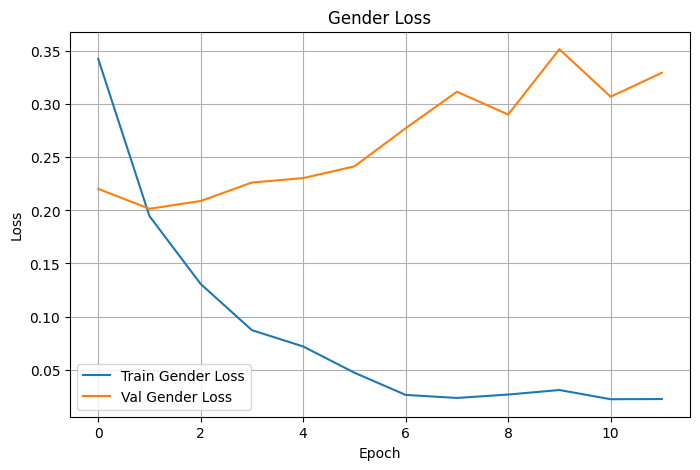

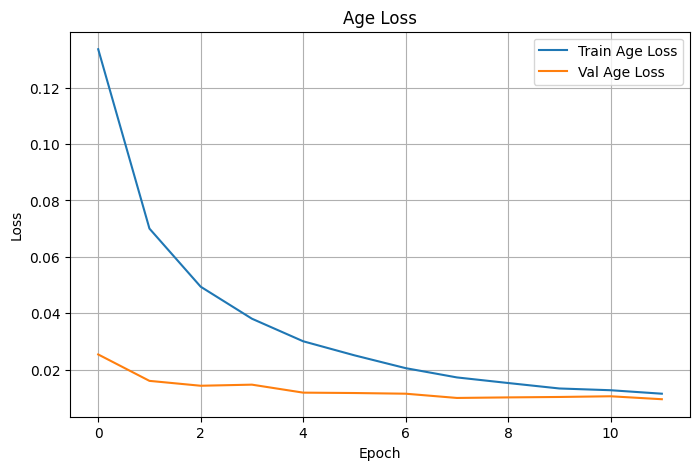

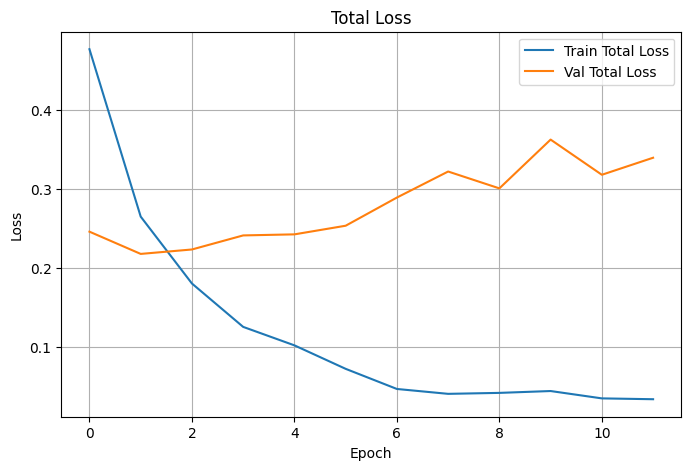

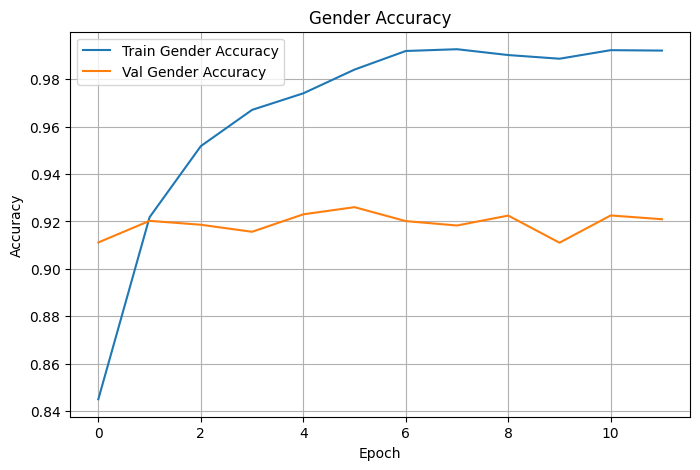

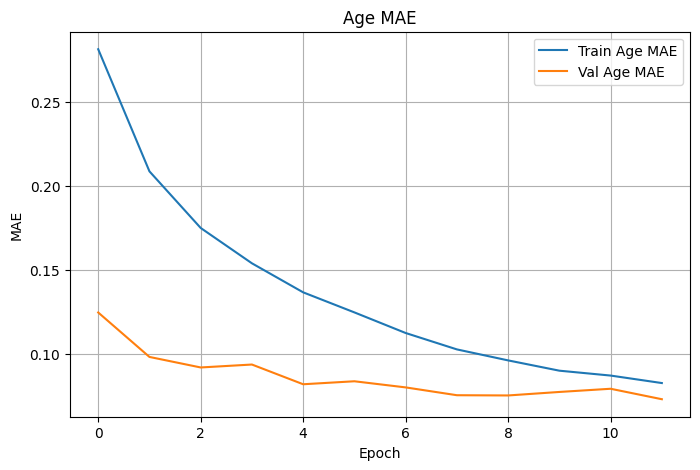

In [19]:
plt.figure(figsize=(8,5))
plt.plot(history["train_gender_loss"], label="Train Gender Loss")
plt.plot(history["val_gender_loss"], label="Val Gender Loss")
plt.title("Gender Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8,5))
plt.plot(history["train_age_loss"], label="Train Age Loss")
plt.plot(history["val_age_loss"], label="Val Age Loss")
plt.title("Age Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8,5))
plt.plot(history["train_total_loss"], label="Train Total Loss")
plt.plot(history["val_total_loss"], label="Val Total Loss")
plt.title("Total Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8,5))
plt.plot(history["train_gender_acc"], label="Train Gender Accuracy")
plt.plot(history["val_gender_acc"], label="Val Gender Accuracy")
plt.title("Gender Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8,5))
plt.plot(history["train_age_mae"], label="Train Age MAE")
plt.plot(history["val_age_mae"], label="Val Age MAE")
plt.title("Age MAE")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.legend()
plt.grid(True)
plt.show()


In [21]:
torch.save(model.state_dict(), "age_gender_mobilenetv2.pt")